In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# Pre-processing

In [2]:
files = os.listdir('res/precision')
column_names = ['_', '__', 'RE-FC Layer 1', 'CE-FC Local Classifier 1', 'CE-FC Layer 2', 'RE-FC Local Classifier 2', 'RE-FC Layer 3', 'CE-FC Local Classifier 3']

In [3]:
dfs1 = [pd.read_csv(f'res/precision/{file}', header=None, names=column_names).iloc[:400,2:] for file in files]
dfs2 = [pd.read_csv(f'res/precision/{file}', header=None, names=column_names).iloc[400:800,2:] for file in files]
dfs3 = [pd.read_csv(f'res/precision/{file}', header=None, names=column_names).iloc[800:,2:] for file in files]
dfs3[0]

,RE-FC Layer 1,CE-FC Local Classifier 1,CE-FC Layer 2,RE-FC Local Classifier 2,RE-FC Layer 3,CE-FC Local Classifier 3
800,41.0,41.0,41.0,41.0,41.0,41.0
801,35.0,41.0,35.0,35.0,35.0,35.0
802,34.0,35.0,34.0,34.0,34.0,34.0
803,34.0,34.0,34.0,34.0,34.0,34.0
804,34.0,34.0,34.0,34.0,34.0,34.0
...,...,...,...,...,...,...
1195,30.0,30.0,30.0,30.0,30.0,30.0
1196,30.0,30.0,30.0,30.0,30.0,30.0
1197,30.0,30.0,30.0,30.0,30.0,30.0
1198,30.0,30.0,30.0,30.0,30.0,30.0


In [4]:
# Stack dataframes along a new axis and compute mean along that axis
mean_df1 = np.mean(dfs1, axis=0)
mean_df1 = pd.DataFrame(mean_df1, columns=column_names[2:])

mean_df2 = np.mean(dfs2, axis=0)
mean_df2 = pd.DataFrame(mean_df2, columns=column_names[2:])

mean_df3 = np.mean(dfs3, axis=0)
mean_df3 = pd.DataFrame(mean_df3, columns=column_names[2:])
mean_df3

,RE-FC Layer 1,CE-FC Local Classifier 1,CE-FC Layer 2,RE-FC Local Classifier 2,RE-FC Layer 3,CE-FC Local Classifier 3
0,41.0,41.000000,41.0,41.0,41.0,41.0
1,35.0,41.000000,35.0,35.0,35.0,35.0
2,34.0,35.000000,34.0,34.0,34.0,34.0
3,34.0,34.000000,34.0,34.0,34.0,34.0
4,34.0,34.000000,34.0,34.0,34.0,34.0
...,...,...,...,...,...,...
395,30.0,30.333333,30.0,30.0,30.0,30.0
396,30.0,30.333333,30.0,30.0,30.0,30.0
397,30.0,30.333333,30.0,30.0,30.0,30.0
398,30.0,30.333333,30.0,30.0,30.0,30.0


In [5]:
# Stack dataframes along a new axis and compute std along that axis
std_df1 = np.std(dfs1, axis=0)
std_df1 = pd.DataFrame(std_df1, columns=column_names[2:])

std_df2 = np.std(dfs2, axis=0)
std_df2 = pd.DataFrame(std_df2, columns=column_names[2:])

std_df3 = np.std(dfs3, axis=0)
std_df3 = pd.DataFrame(std_df3, columns=column_names[2:])
std_df3

,RE-FC Layer 1,CE-FC Local Classifier 1,CE-FC Layer 2,RE-FC Local Classifier 2,RE-FC Layer 3,CE-FC Local Classifier 3
0,0.0,0.000000,0.0,0.0,0.0,0.0
1,0.0,0.000000,0.0,0.0,0.0,0.0
2,0.0,0.000000,0.0,0.0,0.0,0.0
3,0.0,0.000000,0.0,0.0,0.0,0.0
4,0.0,0.000000,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...
395,0.0,0.471405,0.0,0.0,0.0,0.0
396,0.0,0.471405,0.0,0.0,0.0,0.0
397,0.0,0.471405,0.0,0.0,0.0,0.0
398,0.0,0.471405,0.0,0.0,0.0,0.0


# Plot

In [6]:
params = {
   'font.size': 26,
   'axes.linewidth': 1.25,
   'axes.labelsize': 30,
   'legend.fontsize': 22,
   'xtick.labelsize': 26,
   'ytick.labelsize': 26,
   'pdf.fonttype': 42,
   'ps.fonttype': 42
}
plt.rcParams.update(params)

In [7]:
x_label = r'Iteration $t$'
y_label = 'Precision (number of bits)'

In [8]:
from palettable.colorbrewer.qualitative import Set2_6
colors = Set2_6.mpl_colors

### EMLP-1

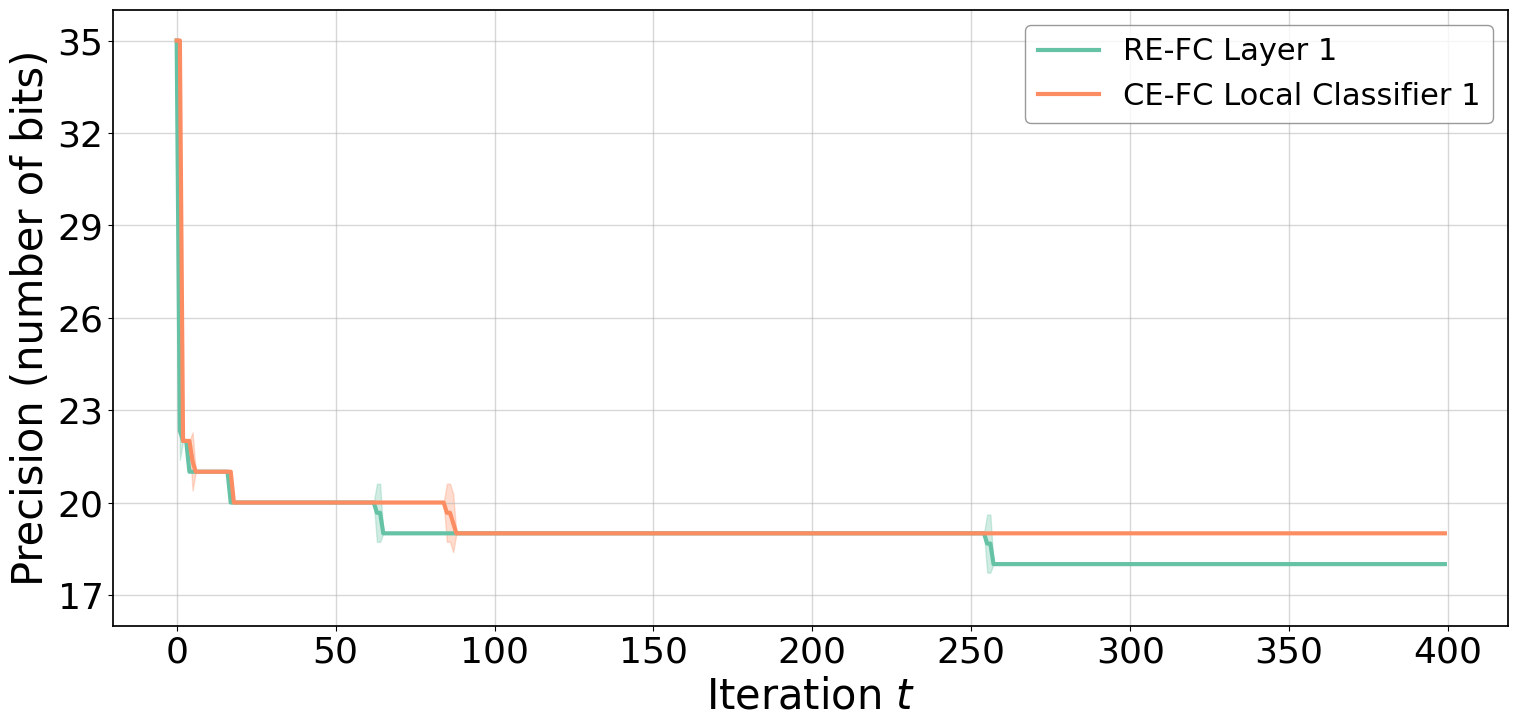

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(18, 8))
ax.set_xlabel(x_label)
ax.set_ylabel(y_label)

# Iterate over each column (layer) to create individual plots for each layer across iterations
for layer, color, label in zip(mean_df1.columns, colors, column_names[2:4]):
    # Extract mean and std values for the current layer (column)
    mean_values = mean_df1[layer].values  # Mean values for the current layer across iterations
    std_values = std_df1[layer].values    # Standard deviation values for the current layer across iterations

    # Define the confidence bounds
    lower_bound = mean_values - std_values * 2
    upper_bound = mean_values + std_values * 2

    # Plot the mean values and the confidence bounds
    plt.plot(mean_df1.index, mean_values, label=label, linewidth=3, color=color)
    plt.fill_between(mean_df1.index, lower_bound, upper_bound, alpha=0.3, color=color)
    
# ax.xaxis.set_tick_params(rotation=45)
ax.tick_params(axis='x')
ax.tick_params(axis='y')  
# ax.set_yscale('log')  
ax.set_ylim(16, 36)
ax.set_yticks(list(range(17, 36, 3)))

legend = ax.legend()
frame = legend.get_frame()
frame.set_edgecolor('0.5')
ax.grid(linewidth=1, alpha=0.5, axis='both')

In [10]:
from pathlib import Path

fn = Path(f'out/layers_precision_emlp1.pdf')
fig.savefig(fn, bbox_inches='tight')

### EMLP-2

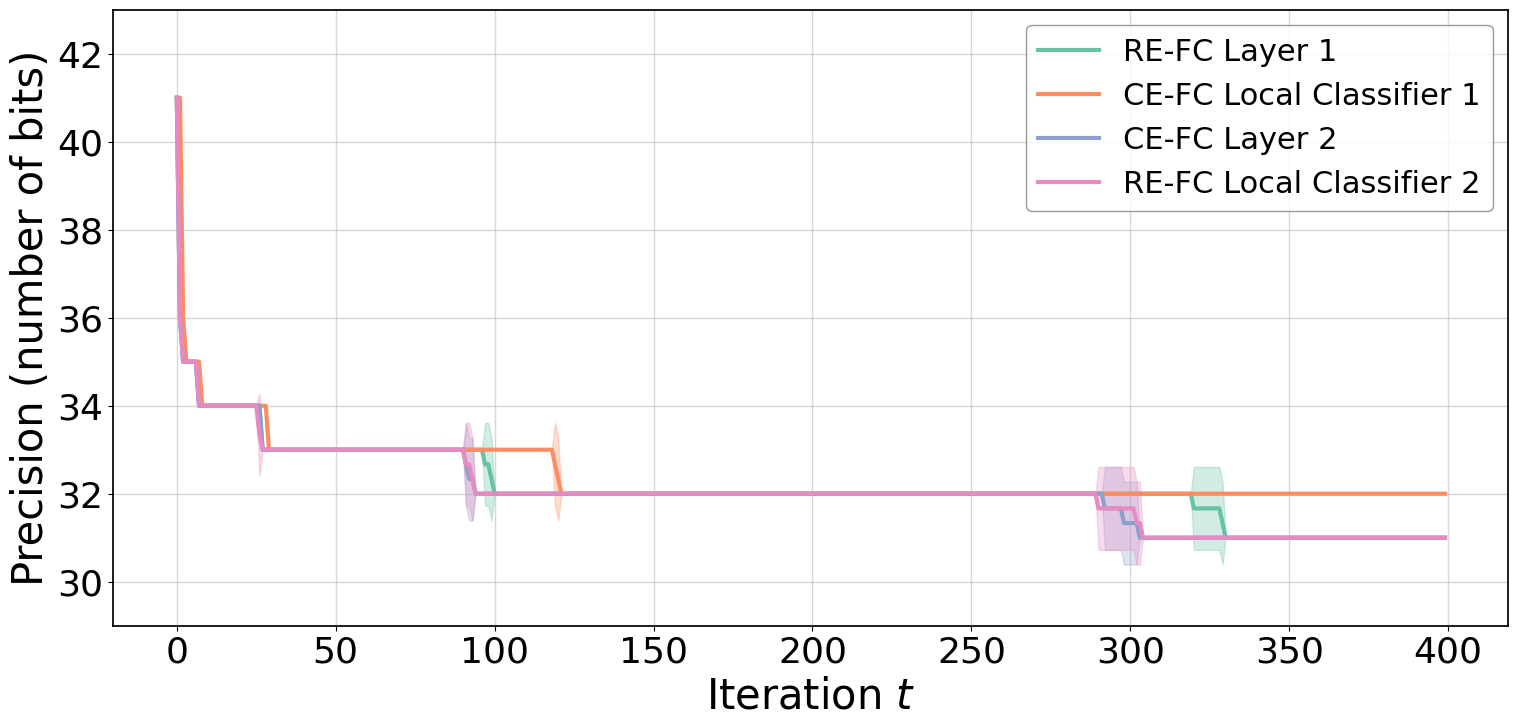

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(18, 8))
ax.set_xlabel(x_label)
ax.set_ylabel(y_label)

# Iterate over each column (layer) to create individual plots for each layer across iterations
for layer, color, label in zip(mean_df2.columns, colors, column_names[2:6]):
    # Extract mean and std values for the current layer (column)
    mean_values = mean_df2[layer].values  # Mean values for the current layer across iterations
    std_values = std_df2[layer].values    # Standard deviation values for the current layer across iterations

    # Define the confidence bounds
    lower_bound = mean_values - std_values * 2
    upper_bound = mean_values + std_values * 2

    # Plot the mean values and the confidence bounds
    plt.plot(mean_df2.index, mean_values, label=label, linewidth=3, color=color)
    plt.fill_between(mean_df2.index, lower_bound, upper_bound, alpha=0.3, color=color)
    
# ax.xaxis.set_tick_params(rotation=45)
ax.tick_params(axis='x')
ax.tick_params(axis='y')  
# ax.set_yscale('log')  
ax.set_ylim(29, 43)
ax.set_yticks(list(range(30, 44, 2)))

legend = ax.legend()
frame = legend.get_frame()
frame.set_edgecolor('0.5')
ax.grid(linewidth=1, alpha=0.5, axis='both')

In [12]:
from pathlib import Path

fn = Path(f'out/layers_precision_emlp2.pdf')
fig.savefig(fn, bbox_inches='tight')

### EMLP-3

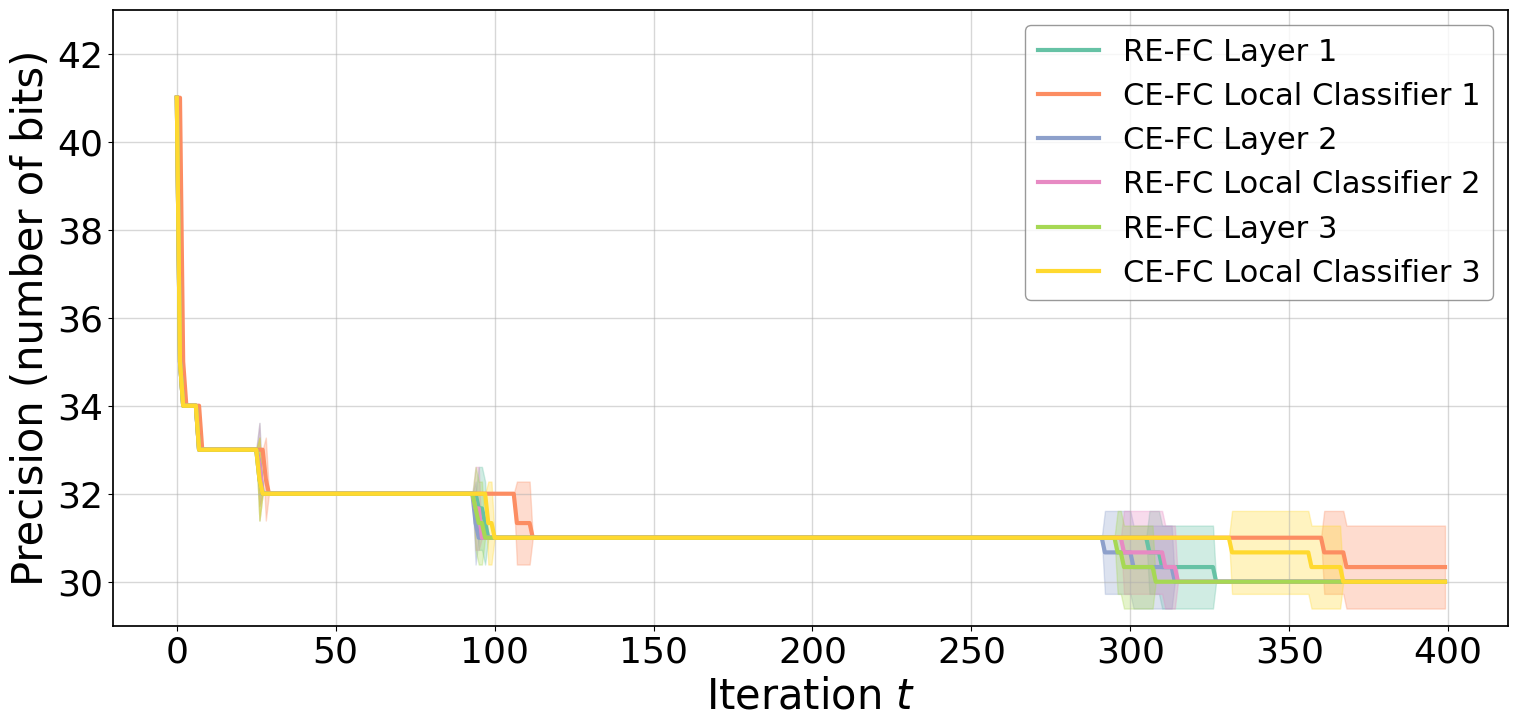

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(18, 8))
ax.set_xlabel(x_label)
ax.set_ylabel(y_label)

# Iterate over each column (layer) to create individual plots for each layer across iterations
for layer, color, label in zip(mean_df3.columns, colors, column_names[2:]):
    # Extract mean and std values for the current layer (column)
    mean_values = mean_df3[layer].values  # Mean values for the current layer across iterations
    std_values = std_df3[layer].values    # Standard deviation values for the current layer across iterations

    # Define the confidence bounds
    lower_bound = mean_values - std_values * 2
    upper_bound = mean_values + std_values * 2

    # Plot the mean values and the confidence bounds
    plt.plot(mean_df3.index, mean_values, label=label, linewidth=3, color=color)
    plt.fill_between(mean_df3.index, lower_bound, upper_bound, alpha=0.3, color=color)
    
# ax.xaxis.set_tick_params(rotation=45)
ax.tick_params(axis='x')
ax.tick_params(axis='y')  
# ax.set_yscale('log')  
ax.set_ylim(29, 43)
ax.set_yticks(list(range(30, 44, 2)))

legend = ax.legend()
frame = legend.get_frame()
frame.set_edgecolor('0.5')
ax.grid(linewidth=1, alpha=0.5, axis='both')

In [14]:
from pathlib import Path

fn = Path(f'out/layers_precision_emlp3.pdf')
fig.savefig(fn, bbox_inches='tight')